# 有监督学习之分类与回归

分类与回归概述
有监督学习主要用来处理分类和回归问题
分类问题是根据特征值预测离散化的标签值
回归问题是根据输入的特征值预测一个连续的值

## 线性回归

### 普通线性回归

普通线性回归即是普通最小二乘法.目标是使用预测目标值与实际目标值的均方误差最小,即MES最小

模型训练的目标也可以是最小化残差平方和RSS

In [2]:
#加州房价数据集线性回归
from sklearn.datasets import fetch_california_housing
#加载数据集
data_home ='./data/california_housing.csv'
#如果指定路径不存在文件,则下载
housing = fetch_california_housing(data_home = '/data')
print('加载对象的关键字:\n',housing.keys())
print('特征名称列表:\n',housing['feature_names'])
print('特征数据集的前两行:\n',housing.data[:2])

加载对象的关键字:
 dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
特征名称列表:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
特征数据集的前两行:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]]


In [3]:
#划分训练集和测试集
from sklearn.model_selection import train_test_split
x = housing.data
y = housing.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [6]:
# 计算各个特征与目标值（房价中位数）之间的相关系数并进行可视化（注：可视化部分代码未在此处展示）
import numpy as np
import pandas as pd

# 构建列名列表，包含所有特征名称和目标值列名"房价中位数"
# housing['feature_names']应是存储所有特征名称的列表
columns_list = list(housing['feature_names']) + ['房价中位数']

# 将训练集的特征数据(x_train)和目标值(y_train)合并为一个数组
# y_train[:,np.newaxis]将一维的y_train转换为二维数组，以便与x_train进行水平堆叠
train_array = np.hstack((x_train,y_train[:,np.newaxis]))

# 同理，将测试集的特征数据(x_test)和目标值(y_test)合并为一个数组
test_array = np.hstack((x_test,y_test[:,np.newaxis]))

# 将合并后的训练集数组转换为DataFrame，使用之前构建的列名列表
train_df_all = pd.DataFrame(train_array,columns=columns_list)

# 同理，将合并后的测试集数组转换为DataFrame
test_df_all = pd.DataFrame(test_array,columns=columns_list)

# 计算训练集DataFrame中所有特征与目标值之间的相关系数矩阵
train_corr_matrix = train_df_all.corr()

# 打印房价中位数与各个特征之间的相关系数，并按降序排列
# sep='' 表示打印时不使用默认分隔符，使输出更紧凑
print('房价中位数与特征属性之间的相关系数:\n',train_corr_matrix['房价中位数'].sort_values(ascending =False),sep='')

房价中位数与特征属性之间的相关系数:
房价中位数         1.000000
MedInc        0.692758
AveRooms      0.154426
HouseAge      0.106470
Population   -0.027053
AveOccup     -0.033169
AveBedrms    -0.044415
Longitude    -0.047277
Latitude     -0.142702
Name: 房价中位数, dtype: float64


为方便阐述,根据各特征与房价中位数之间的相关系数,各取绝对值最大的两个正相关特征MedInc与AveRooms和两个负相关特征Latitude与Longitude,而忽略其他数据.

C:\Users\86157\AppData\Local\Temp\ipykernel_25880\1083173059.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'房价中位数'] = y_train


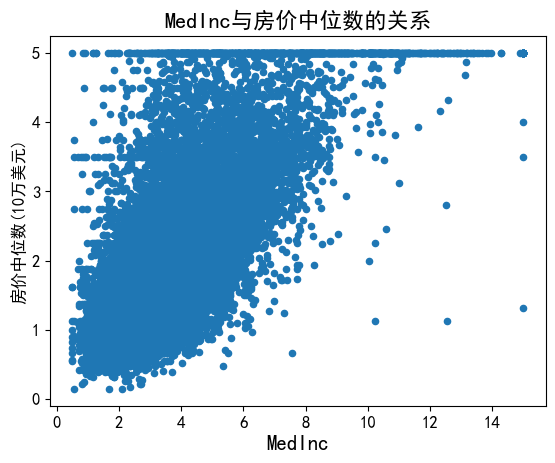

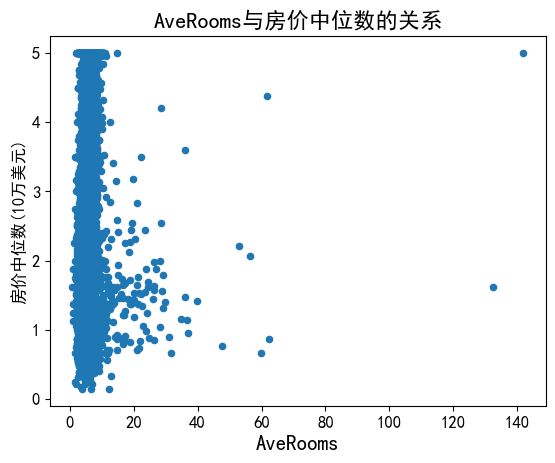

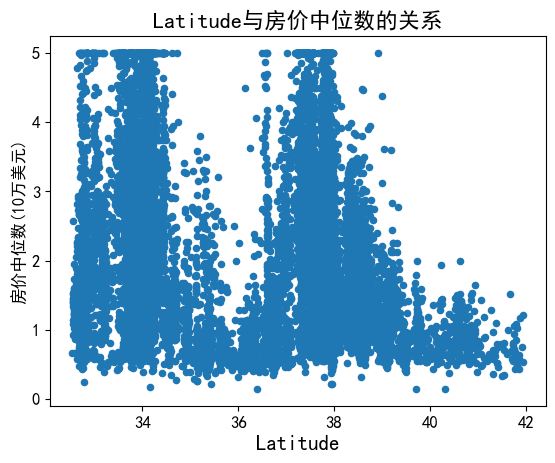

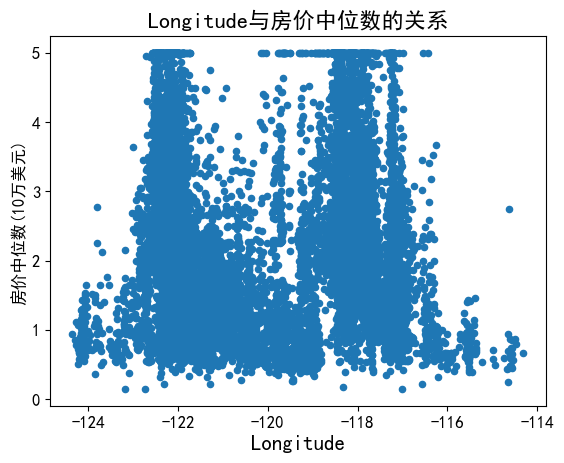

In [27]:
# 选取需要分析的特征列表
# MedInc(收入中位数)、AveRooms(平均房间数)、Latitude(纬度)、Longitude(经度)
feature_name_list = ['MedInc','AveRooms','Latitude','Longitude']

# 从训练集数据中筛选出需要分析的特征列
df_train = train_df_all[feature_name_list]

# 将筛选后的特征数据转换为数组格式，用于后续模型训练
x_train= df_train.values

# 为训练集DataFrame添加目标值列"房价中位数"，便于后续可视化分析
df_train.loc[:,'房价中位数'] = y_train

# 从测试集数据中筛选出相同的特征列
df_test = test_df_all[feature_name_list]

# 将测试集特征数据转换为数组格式
x_test = df_test.values

# 导入可视化所需的库
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# 设置中文字体，确保中文正常显示
plt.rcParams['font.family'] = 'SimHei'
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 遍历每个特征，绘制与房价中位数的散点图
for name in feature_name_list:
    # 绘制散点图，x轴为当前特征，y轴为房价中位数
    df_train.plot(kind = 'scatter',x = name,y = '房价中位数')
    # 设置x轴刻度字体大小
    plt.xticks(fontsize = 12)
    # 设置y轴刻度字体大小
    plt.yticks(fontsize = 12)
    # 设置x轴标签及字体大小
    plt.xlabel(name,fontsize = 15)
    # 设置y轴标签及字体大小，注明单位为10万美元
    plt.ylabel('房价中位数(10万美元)',fontsize = 12)
    # 设置图表标题，显示当前特征与房价中位数的关系
    plt.title('{}与房价中位数的关系'.format(name),fontsize = 16)
    # 显示图表（原代码缺少plt.show()，通常需要添加以显示图像）
    # plt.show()

In [18]:
#构建模型
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
print('模型的特征权重:',model.coef_)
print('特征名称:',feature_name_list)
print('截距是:',model.intercept_)

模型的特征权重: [ 0.36032084  0.0157055  -0.49656162 -0.51096321]
特征名称: ['MedInc', 'AveRooms', 'Latitude', 'Longitude']
截距是: -42.811932946049176


In [20]:
#预测目标值
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
print('测试集第一个预测目标值:',y_test_pred[:1])
print('测试机第一个真实值:',y_test[:1])
x_new_data = [[8,7,38,-122]]
print('新数据的预测目标值:',model.predict(x_new_data))

测试集第一个预测目标值: [2.403255]
测试机第一个真实值: [1.369]
新数据的预测目标值: [3.64874271]


In [25]:
#模型性能评估
#决定系数R平方
print('训练集的决定系数R平方:',model.score(x_train,y_train))
print('测试集的决定系数R平方:',model.score(x_test,y_test))
#计算均方误差
from sklearn import metrics
train_mean_squared_error = metrics.mean_squared_error(y_train,y_train_pred)
test_mean_squared_error = metrics.mean_squared_error(y_test,y_test_pred)
print('训练集的均方误差:{:.2f}'.format(train_mean_squared_error))
print('测试集的均方误差:{:.2f}'.format(test_mean_squared_error))

训练集的决定系数R平方: 0.5894298141364945
测试集的决定系数R平方: 0.5672465391760795
训练集的均方误差:0.55
测试集的均方误差:0.56


In [26]:
#使用完整特征数据集训练
x = housing.data
y = housing.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
model = LinearRegression()
model.fit(x_train,y_train)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
#决定系数R平方
print('训练集的决定系数R平方:',model.score(x_train,y_train))
print('测试集的决定系数R平方:',model.score(x_test,y_test))
#计算均方误差
from sklearn import metrics
train_mean_squared_error = metrics.mean_squared_error(y_train,y_train_pred)
test_mean_squared_error = metrics.mean_squared_error(y_test,y_test_pred)
print('训练集的均方误差:{:.2f}'.format(train_mean_squared_error))
print('测试集的均方误差:{:.2f}'.format(test_mean_squared_error))

训练集的决定系数R平方: 0.6088968118672871
测试集的决定系数R平方: 0.5943232652466173
训练集的均方误差:0.52
测试集的均方误差:0.53


## 岭回归

In [47]:
#加载数据
from sklearn.datasets import fetch_california_housing
#加载数据集
data_home ='./data/california_housing.csv'
#如果指定路径不存在文件,则下载
housing = fetch_california_housing(data_home = '/data')
print('加载对象的关键字:\n',housing.keys())
print('特征名称列表:\n',housing['feature_names'])
print('特征数据集的前两行:\n',housing.data[:2])
x = housing.data
y = housing.target

加载对象的关键字:
 dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
特征名称列表:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
特征数据集的前两行:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]]


In [48]:
#划分训练测试集
from sklearn.model_selection  import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [49]:
#正则化训练前要先标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_std = scaler.transform(x_train)
x_test_std = scaler.transform(x_test)

In [50]:
#创建模型学习模型参数
from sklearn.linear_model import Ridge
model = Ridge(alpha=0.5)
model.fit(x_train_std,y_train)
print('模型的特征权重:',model.coef_)
print('特征名称;',housing['feature_names'])
print('截距:',model.intercept_)

模型的特征权重: [ 0.82623412  0.11714232 -0.24883282  0.29028379 -0.00862803 -0.0305691
 -0.90003058 -0.87019179]
特征名称; ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
截距: 2.072498958938836


In [53]:
#模型根据训练的参数和特征值预测目标值
y_train_pred = model.predict(x_train_std)
y_test_pred = model.predict(x_test_std)
print('测试集第一个预测的目标值:',y_test_pred[:1])
print('测试集第一个实际值:',y_test[:1])
x_new = [[8,41,7,1,322,2.6,38,-122]]
x_new_std = scaler.transform(x_new)
print('新数据的预测目标值:',model.predict(x_new_std))

测试集第一个预测的目标值: [2.28103284]
测试集第一个实际值: [1.369]
新数据的预测目标值: [3.8302636]


In [54]:
#计算模型性能
#决定系数R平方
print('训练集的决定系数R平方:',model.score(x_train_std,y_train))
print('测试集的决定系数R平方:',model.score(x_test_std,y_test))
#计算均方误差
from sklearn import metrics
train_mean_squared_error = metrics.mean_squared_error(y_train,y_train_pred)
test_mean_squared_error = metrics.mean_squared_error(y_test,y_test_pred)
print('训练集的均方误差:{:.2f}'.format(train_mean_squared_error))
print('测试集的均方误差:{:.2f}'.format(test_mean_squared_error))

训练集的决定系数R平方: 0.6088967948939551
测试集的决定系数R平方: 0.5943187159242967
训练集的均方误差:0.52
测试集的均方误差:0.53


In [55]:
#RidgeCV
import numpy as np
from sklearn.linear_model import RidgeCV
model_CV = RidgeCV(alphas = np.arange(0.000001,10,1000))
model_CV.fit(x_train_std,y_train)
y_test_predict = model_CV.predict(x_test_std)
print('给的alpha中的最佳值:',model_CV.alpha_)
print('最佳alpha下模型的系数:',model_CV.coef_)
print('最佳alpha下模型的截距:',model_CV.intercept_)
print('最佳alpha下模型训练集决定系数:',model_CV.score(x_train_std,y_train))
print('最佳alpha下模型测试集决定系数:',model_CV.score(x_test_std,y_test))

给的alpha中的最佳值: 1e-06
最佳alpha下模型的系数: [ 0.82623409  0.11709831 -0.24891245  0.29039374 -0.00864193 -0.03056678
 -0.90041954 -0.87058577]
最佳alpha下模型的截距: 2.072498958938836
最佳alpha下模型训练集决定系数: 0.6088968116757778
最佳alpha下模型测试集决定系数: 0.5943234380805966


## lasso回归(套索回归)

In [56]:
#加州房价数据集线性回归
from sklearn.datasets import fetch_california_housing
#加载数据集
data_home ='./data/california_housing.csv'
#如果指定路径不存在文件,则下载
housing = fetch_california_housing(data_home = '/data')
x,y = housing.data,housing.target

In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_std = scaler.transform(x_train)
x_test_std = scaler.transform(x_test)
from sklearn.linear_model import Lasso
model_lasso = Lasso(alpha=0.8)
model_lasso.fit(x_train_std,y_train)
print('模型的特征权重:',model_lasso.coef_)
print('特征名称:',housing.feature_names)
print('截距:',model_lasso.intercept_)

模型的特征权重: [ 0.00143833  0.          0.         -0.         -0.         -0.
 -0.         -0.        ]
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
截距: 2.072498958938953


In [61]:
#预测
y_train_pred = model_lasso.predict(x_train_std)
y_test_pred  = model_lasso.predict(x_test_std)
print('预测测试集的第一个值:',y_test_pred[:1])
print('测试集的实际值:',y_test[:1])
x_new = [[8,41,7,1,322,2.6,38,-122]]
x_new_std = scaler.transform(x_new)
print('新数据的预测目标值:',model_lasso.predict(x_new_std))

预测测试集的第一个值: [2.07270678]
测试集的实际值: [1.369]
新数据的预测目标值: [2.07560965]


In [62]:
#计算模型性能
#决定系数R平方
print('训练集的决定系数R平方:',model.score(x_train_std,y_train))
print('测试集的决定系数R平方:',model.score(x_test_std,y_test))
#计算均方误差
from sklearn import metrics
train_mean_squared_error = metrics.mean_squared_error(y_train,y_train_pred)
test_mean_squared_error = metrics.mean_squared_error(y_test,y_test_pred)
print('训练集的均方误差:{:.2f}'.format(train_mean_squared_error))
print('测试集的均方误差:{:.2f}'.format(test_mean_squared_error))

训练集的决定系数R平方: 0.6088967948939551
测试集的决定系数R平方: 0.5943187159242967
训练集的均方误差:1.34
测试集的均方误差:1.30


In [64]:
#LassoCV
import numpy as np
from sklearn.linear_model import LassoCV
model_Lasso_CV = LassoCV(alphas = np.arange(0.000001,10,1000))
model_Lasso_CV.fit(x_train_std,y_train)
y_test_predict = model_Lasso_CV.predict(x_test_std)
print('给的alpha中的最佳值:',model_Lasso_CV.alpha_)
print('最佳alpha下模型的系数:',model_Lasso_CV.coef_)
print('最佳alpha下模型的截距:',model_Lasso_CV.intercept_)
print('最佳alpha下模型训练集决定系数:',model_Lasso_CV.score(x_train_std,y_train))
print('最佳alpha下模型测试集决定系数:',model_Lasso_CV.score(x_test_std,y_test))

给的alpha中的最佳值: 1e-06
最佳alpha下模型的系数: [ 0.82624276  0.11710158 -0.24889657  0.29037344 -0.0086421  -0.03056359
 -0.90041021 -0.87057416]
最佳alpha下模型的截距: 2.072498958938836
最佳alpha下模型训练集决定系数: 0.6088968118249294
最佳alpha下模型测试集决定系数: 0.5943229751546083


## 多项回归

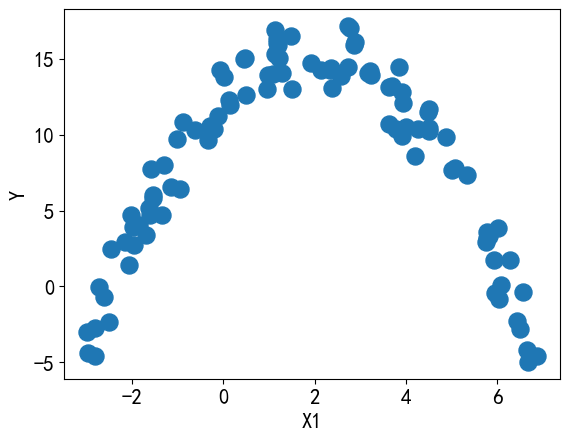

In [26]:
import numpy as np
samples = 100
np.random.seed(1)
x1 = 10 * np.random.rand(samples,1) - 3
np.random.seed(10)
y  = -0.8 * x1 ** 2 + 3 * x1 + 10 + 5 * np.random.rand(samples,1)
import matplotlib.pyplot as plt
plt.scatter(x1,y,s=150)
plt.xlabel('X1',size = 15)
plt.ylabel('Y',size = 15)
plt.xticks(size=15)
plt.yticks(size=15)
plt.show()

In [27]:
#利用PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures
polymodel = PolynomialFeatures(degree = 2, include_bias= False)
#可以分两部分别完成fit与transform
polymodel.fit(x1)
x1_poly = polymodel.transform(x1)
print('第0个样本的特征值x1[0]:',x1[0])
print('第0个样本多项式特征值x1_poly[0]:',x1_poly[0])

第0个样本的特征值x1[0]: [1.17022005]
第0个样本多项式特征值x1_poly[0]: [1.17022005 1.36941496]


In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x1_poly,y,test_size=0.2,random_state=10)
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)
print('模型的特征权重:',linear_model.coef_)
print('截距:',linear_model.intercept_)
print('训练集的决定系数R平方:',linear_model.score(x_train,y_train))
print('测试集的决定系数R平方:',linear_model.score(x_test,y_test))

模型的特征权重: [[ 3.13346026 -0.8212209 ]]
截距: [12.45900801]
训练集的决定系数R平方: 0.9551735671839119
测试集的决定系数R平方: 0.931243298678541


C:\Users\86157\AppData\Local\Temp\ipykernel_8040\1175501775.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_model = np.arange(min(x1) - 0.5,max(x1) + 1,0.1)


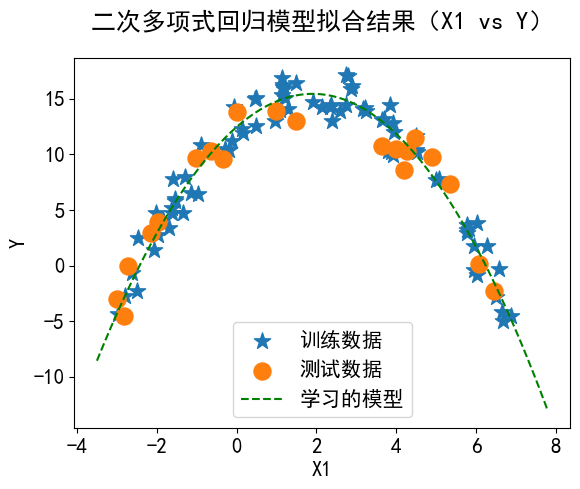

In [29]:
#可视化
x_model = np.arange(min(x1) - 0.5,max(x1) + 1,0.1)
#可以将x_model的2次幂和x_model各看成一个特征
y_model = (linear_model.coef_[0][1] * x_model ** 2) + (linear_model.coef_[0][0] * x_model) + linear_model.intercept_
#绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus']  = False
plt.scatter(x_train[:,0],y_train,marker = '*',s = 150 ,label = '训练数据')
plt.scatter(x_test[:,0],y_test,marker = 'o',s = 150,label = '测试数据' )
plt.plot(x_model,y_model,'g--',label= '学习的模型')
plt.title('二次多项式回归模型拟合结果（X1 vs Y）', size=18, pad=20)  # pad=20：标题与图表的间距
plt.xlabel('X1',size = 15)
plt.ylabel('Y',size = 15)
plt.xticks(size=15)
plt.yticks(size=15)
plt.legend(prop = {'size':15})
plt.show()

正在加载数据集...
加载对象的关键字:
 dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
特征名称列表:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
特征数据集的前两行:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]]


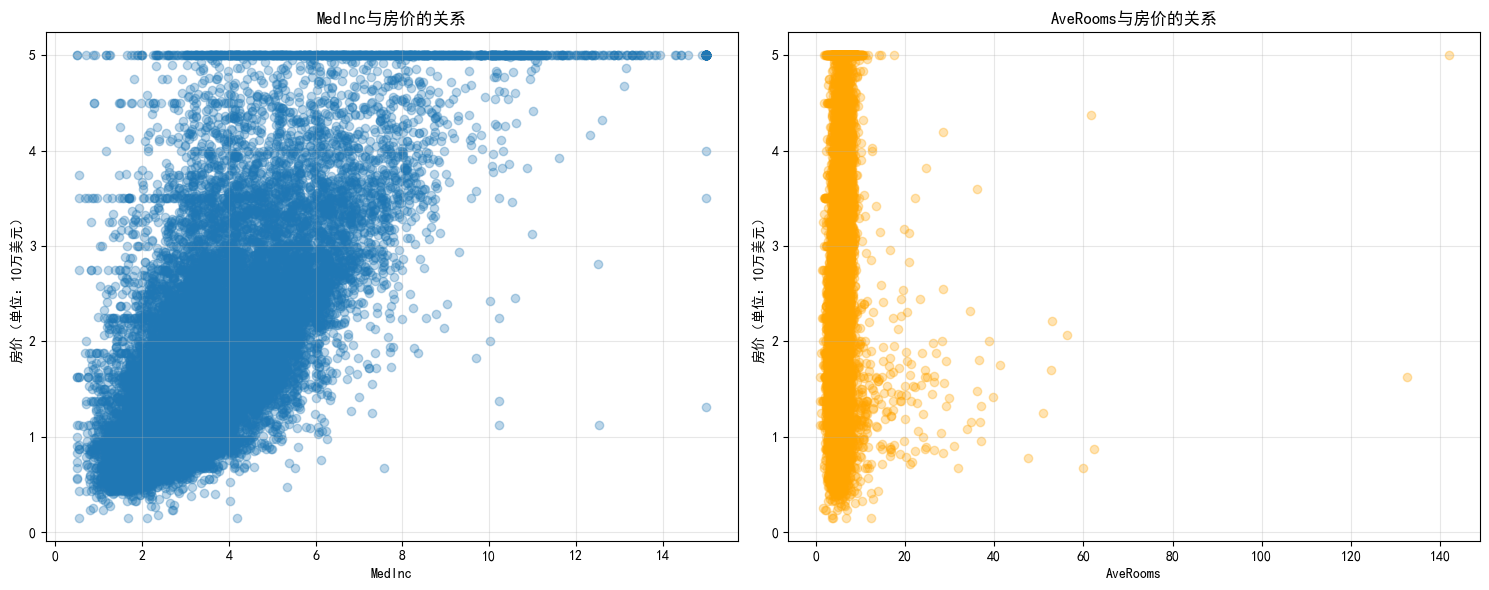


创建多项式特征...
原始特征维度: (20640, 2)
多项式特征维度: (20640, 5)
多项式特征名称: ['MedInc' 'AveRooms' 'MedInc^2' 'MedInc AveRooms' 'AveRooms^2']

训练线性回归模型...

模型的特征权重: [ 0.56945375 -0.11419509 -0.01226218  0.00318988  0.00095262]
截距: 0.605375332756378
训练集的决定系数R平方: 0.4935
测试集的决定系数R平方: 0.5050
训练集MSE: 0.6702
测试集MSE: 0.6755

新数据 [[8, 7]] 的预测值: 3.8022 (10万美元)


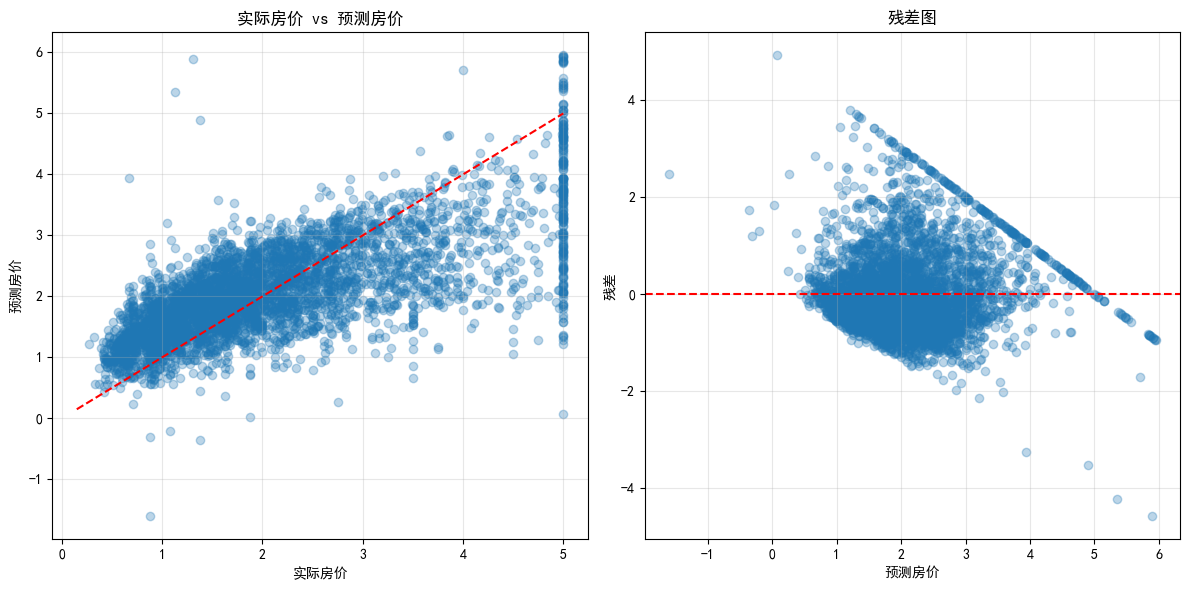

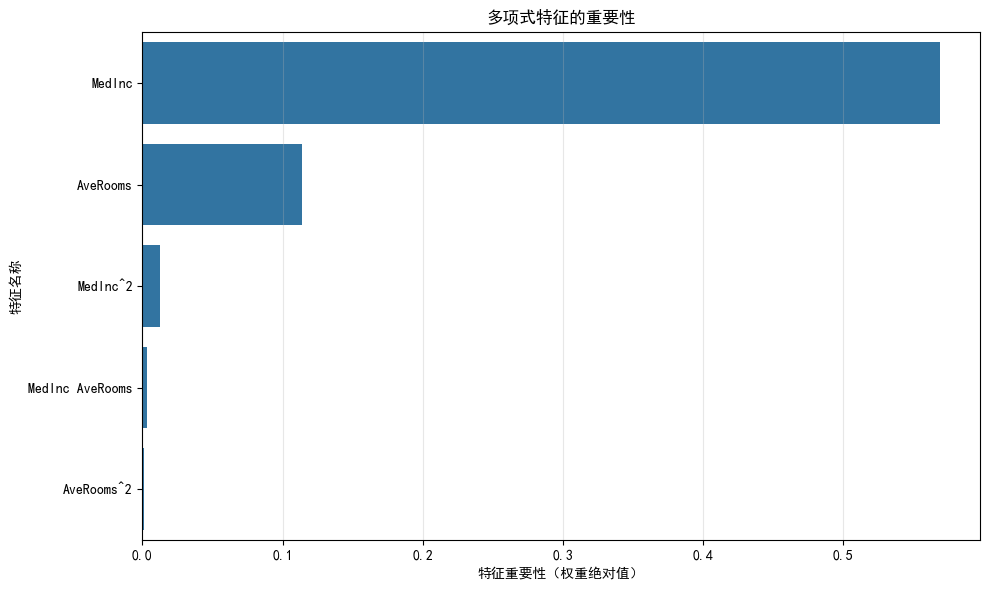

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

# 加载数据集
print("正在加载数据集...")
housing = fetch_california_housing()
print('加载对象的关键字:\n', housing.keys())
print('特征名称列表:\n', housing['feature_names'])
print('特征数据集的前两行:\n', housing.data[:2])

# 选择特征 (0: 平均收入, 2: 平均房间数)
feature_indices = [0, 2]
feature_names = [housing['feature_names'][i] for i in feature_indices]
x = housing.data[:, feature_indices]
y = housing.target

# 1. 数据可视化 - 原始数据分布
plt.figure(figsize=(15, 6))

# 散点图：特征与目标变量的关系
plt.subplot(1, 2, 1)
plt.scatter(x[:, 0], y, alpha=0.3, label=f'{feature_names[0]} vs 房价')
plt.xlabel(feature_names[0])
plt.ylabel('房价（单位：10万美元）')
plt.title(f'{feature_names[0]}与房价的关系')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(x[:, 1], y, alpha=0.3, color='orange', label=f'{feature_names[1]} vs 房价')
plt.xlabel(feature_names[1])
plt.ylabel('房价（单位：10万美元）')
plt.title(f'{feature_names[1]}与房价的关系')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 创建多项式特征矩阵
print("\n创建多项式特征...")
poly_model = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly_model.fit_transform(x)
print(f"原始特征维度: {x.shape}")
print(f"多项式特征维度: {x_poly.shape}")
print(f"多项式特征名称: {poly_model.get_feature_names_out(feature_names)}")

# 划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(
    x_poly, y, test_size=0.2, random_state=10
)

# 训练线性回归模型
print("\n训练线性回归模型...")
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

# 模型评估
print('\n模型的特征权重:', linear_model.coef_)
print('截距:', linear_model.intercept_)
print(f'训练集的决定系数R平方: {linear_model.score(x_train, y_train):.4f}')
print(f'测试集的决定系数R平方: {linear_model.score(x_test, y_test):.4f}')
print(f'训练集MSE: {mean_squared_error(y_train, linear_model.predict(x_train)):.4f}')
print(f'测试集MSE: {mean_squared_error(y_test, linear_model.predict(x_test)):.4f}')

# 新数据预测
x_new = [[8, 7]]
x_new_poly = poly_model.transform(x_new)
print(f'\n新数据 {x_new} 的预测值: {linear_model.predict(x_new_poly)[0]:.4f} (10万美元)')

# 2. 可视化 - 模型预测效果
plt.figure(figsize=(12, 6))

# 预测值与实际值对比
y_pred = linear_model.predict(x_test)
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 理想预测线
plt.xlabel('实际房价')
plt.ylabel('预测房价')
plt.title('实际房价 vs 预测房价')
plt.grid(True, alpha=0.3)

# 残差图
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('预测房价')
plt.ylabel('残差')
plt.title('残差图')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. 可视化 - 特征重要性
plt.figure(figsize=(10, 6))
feature_importance = np.abs(linear_model.coef_)
feature_names_poly = poly_model.get_feature_names_out(feature_names)

sns.barplot(x=feature_importance, y=feature_names_poly)
plt.xlabel('特征重要性（权重绝对值）')
plt.ylabel('特征名称')
plt.title('多项式特征的重要性')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 分类

### 单标签二分类

In [8]:
from sklearn.datasets import make_classification
import pandas as pd
x,y = make_classification(n_samples=600,n_features= 2,n_informative= 2,n_redundant= 0,n_repeated= 0 ,n_classes= 2,n_clusters_per_class=1,random_state=500)
print('各类别样本的数量:\n',pd.Series(y).value_counts(),sep = '')

各类别样本的数量:
1    300
0    300
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,stratify=y,random_state=5)

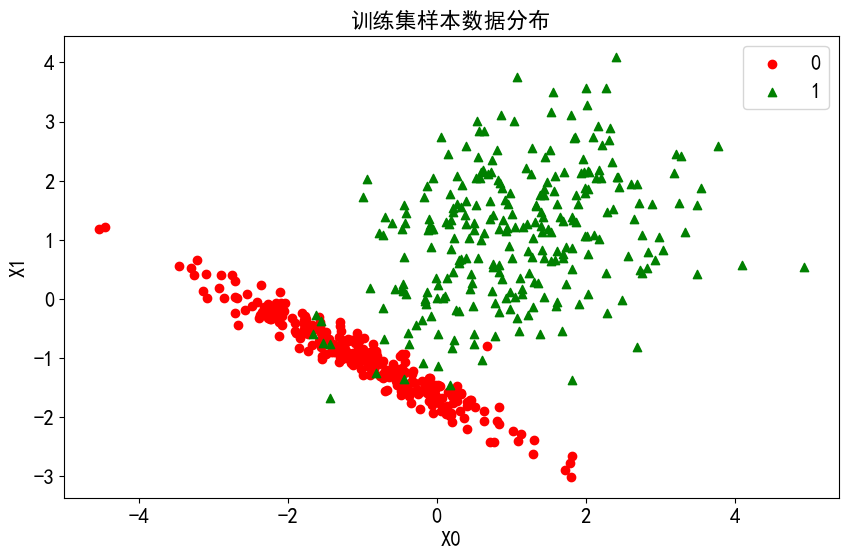

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(10,6))
labels = np.unique(y_train)
colors = ['r','g']
markers = ['o','^']
for label,color,marker in zip(labels,colors,markers):
    loc = np.where(y_train == label)
    x_class = x_train[loc]
    plt.scatter(x_class[:,0],x_class[:,1],c = color,marker=marker,label = label)
plt.xticks(fontsize = 15)
plt.yticks(fontsize =15)
plt.xlabel('X0',fontsize =15)
plt.ylabel('X1',fontsize = 15)
plt.title('训练集样本数据分布',fontdict = {'size':16})
plt.legend(fontsize =15)
plt.show()

In [13]:
#标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_std = scaler.transform(x_train)
x_test_std = scaler.transform(x_test)

In [14]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(x_train_std,y_train)
print('学的的特征权重参数:',lr_model.coef_)
print('样本类型:',lr_model.classes_)
print('学的的模型截距:',lr_model.intercept_)

学的的特征权重参数: [[2.99633456 4.06812673]]
样本类型: [0 1]
学的的模型截距: [2.34093341]


C:\Users\86157\AppData\Local\Temp\ipykernel_19524\1059853966.py:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(
C:\Users\86157\AppData\Local\Temp\ipykernel_19524\1059853966.py:35: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


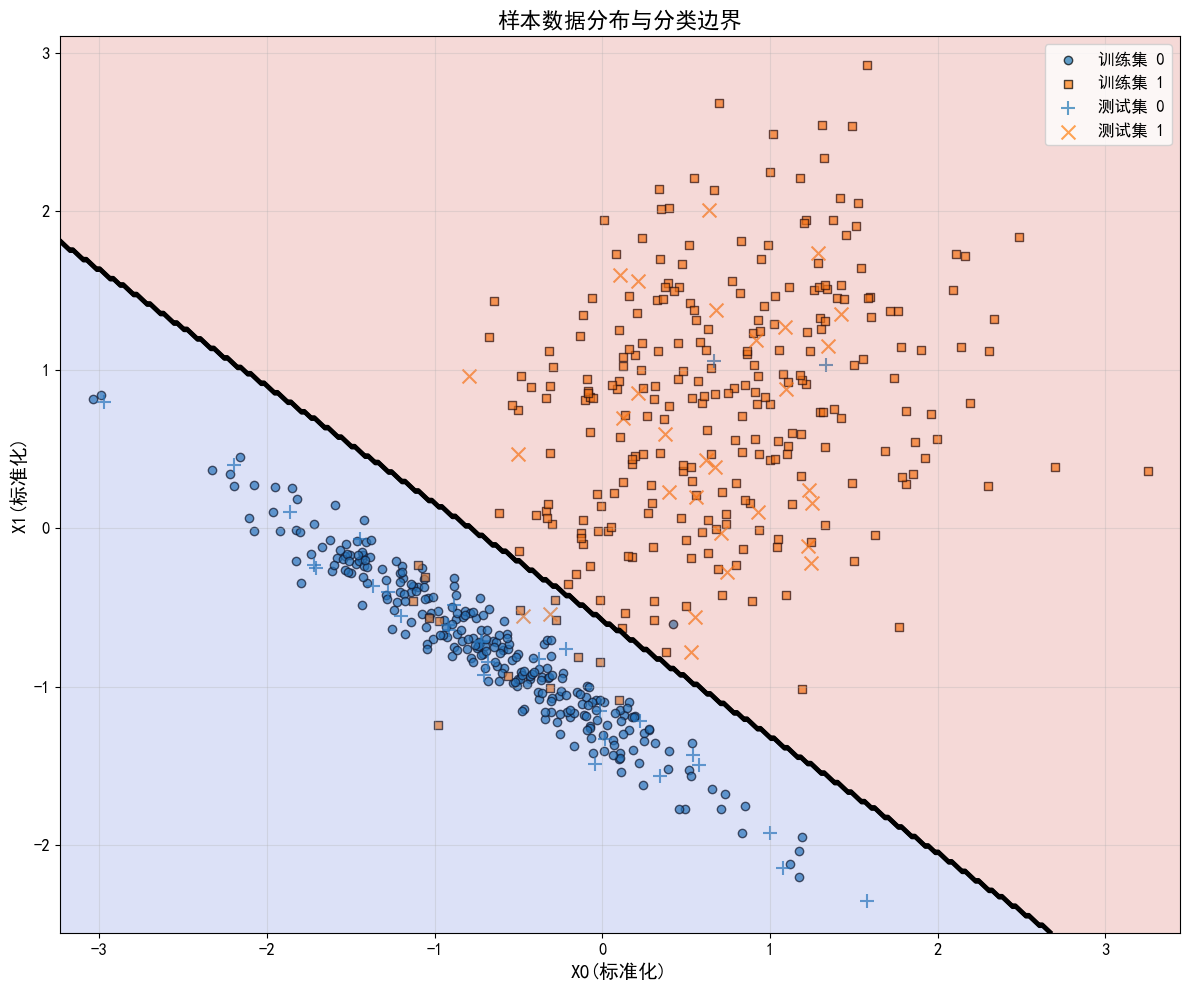

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

# 假设已定义以下变量（根据实际情况调整）
# labels = [0, 1]  # 分类标签
# lr_model  # 已训练好的逻辑回归模型
# x_train_std, x_test_std  # 标准化后的训练集和测试集特征
# y_train, y_test  # 训练集和测试集标签

plt.figure(figsize=(12, 10))

# 绘制训练集样本
train_markers = ['o', 's']  # 圆形和正方形表示训练集
train_colors = ['#1f77b4', '#ff7f0e']  # 蓝色和橙色
for label, color, marker in zip(labels, train_colors, train_markers):
    loc = np.where(y_train == label)
    x_class = x_train_std[loc]
    plt.scatter(
        x_class[:, 0], x_class[:, 1], 
        c=color, marker=marker, 
        label=f'训练集 {label}',
        alpha=0.7, edgecolors='k'  # 增加边缘色和透明度
    )

# 绘制测试集样本
test_markers = ['+', 'x']  # 加号和叉号表示测试集
test_colors = ['#1f77b4', '#ff7f0e']  # 与训练集同色系
for label, color, marker in zip(labels, test_colors, test_markers):
    loc = np.where(y_test == label)
    x_class = x_test_std[loc]
    plt.scatter(
        x_class[:, 0], x_class[:, 1], 
        c=color, marker=marker, 
        label=f'测试集 {label}',
        s=100, alpha=0.7, edgecolors='k'  # 更大的尺寸
    )

# 绘制分类边界
x_std = np.r_[x_train_std, x_test_std]
# 修正线条范围计算
x_min, x_max = x_std[:, 0].min() - 0.2, x_std[:, 0].max() + 0.2
y_min, y_max = x_std[:, 1].min() - 0.2, x_std[:, 1].max() + 0.2

# 生成网格点用于绘制决策边界
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# 预测网格点类别
Z = lr_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界和背景色
plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)
plt.contour(xx, yy, Z, linewidths=2, colors='black')

# 设置坐标轴和标题
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('X0(标准化)', fontsize=14)
plt.ylabel('X1(标准化)', fontsize=14)
plt.title('样本数据分布与分类边界', fontdict={'size': 16})
plt.legend(fontsize=12, loc='best')
plt.grid(alpha=0.3)  # 增加网格线
plt.tight_layout()  # 自动调整布局
plt.show()

In [18]:
#预测
y_train_pred = lr_model.predict(x_train_std)
y_test_pred_label = lr_model.predict(x_test_std)
y_test_pred_proba = lr_model.predict_proba(x_test_std)
print('测试集中前两个样本预测分类的概率:\n',y_test_pred_proba[:2])
print('测试集中前5个样本预测分类的标签:\n',y_test_pred_label[:5])
proba_computed_label = np.argmax(y_test_pred_proba,axis=1)
print('根据概率计算的测试集前5个样本预测标签:\n',proba_computed_label[:5])

测试集中前两个样本预测分类的概率:
 [[8.00797066e-01 1.99202934e-01]
 [4.59874262e-05 9.99954013e-01]]
测试集中前5个样本预测分类的标签:
 [0 1 0 0 1]
根据概率计算的测试集前5个样本预测标签:
 [0 1 0 0 1]


训练集上的准确率: 0.9722222222222222
测试集上的准确率: 0.9333333333333333

混淆矩阵:
[[28  2]
 [ 2 28]]

混淆矩阵元素含义:
真正例 (TP): 28 - 实际为正例且预测为正例
真负例 (TN): 28 - 实际为负例且预测为负例
假正例 (FP): 2 - 实际为负例但预测为正例
假负例 (FN): 2 - 实际为正例但预测为负例

分类概率指标:
准确率 (Accuracy): 0.9333
精确率 (Precision): 0.9333
召回率 (Recall/Sensitivity): 0.9333
特异度 (Specificity): 0.9333
F1分数 (F1 Score): 0.9333
假正例率 (FPR): 0.0667
假负例率 (FNR): 0.0667

详细分类报告:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        30
           1       0.93      0.93      0.93        30

    accuracy                           0.93        60
   macro avg       0.93      0.93      0.93        60
weighted avg       0.93      0.93      0.93        60



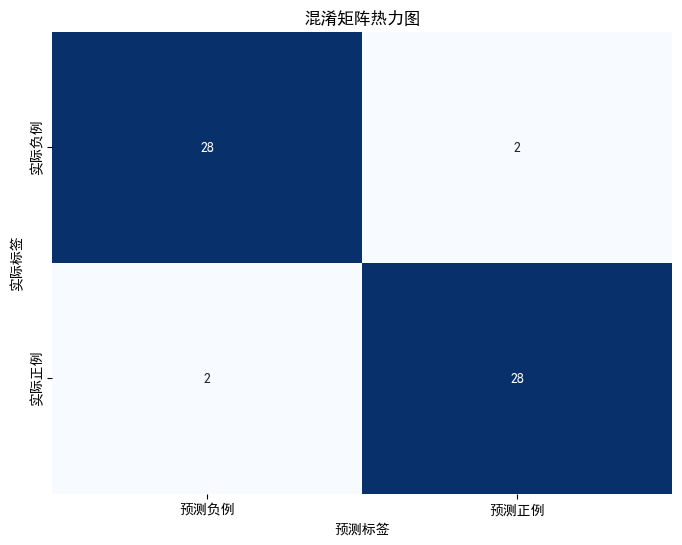

In [20]:
# 模型评估基础指标
from sklearn.metrics import confusion_matrix, classification_report
print('训练集上的准确率:', lr_model.score(x_train_std, y_train))
print('测试集上的准确率:', lr_model.score(x_test_std, y_test))

# 预测测试集结果
y_pred = lr_model.predict(x_test_std)

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 提取混淆矩阵元素
tn, fp, fn, tp = cm.ravel()  # 适用于二分类问题

# 计算各类概率指标
accuracy = (tp + tn) / (tp + tn + fp + fn)  # 准确率
precision = tp / (tp + fp) if (tp + fp) > 0 else 0  # 精确率
recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # 召回率
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # 特异度
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0  # F1分数
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0  # 假正例率
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0  # 假负例率

# 打印混淆矩阵及指标
print("\n混淆矩阵:")
print(cm)
print("\n混淆矩阵元素含义:")
print(f"真正例 (TP): {tp} - 实际为正例且预测为正例")
print(f"真负例 (TN): {tn} - 实际为负例且预测为负例")
print(f"假正例 (FP): {fp} - 实际为负例但预测为正例")
print(f"假负例 (FN): {fn} - 实际为正例但预测为负例")

print("\n分类概率指标:")
print(f"准确率 (Accuracy): {accuracy:.4f}")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall/Sensitivity): {recall:.4f}")
print(f"特异度 (Specificity): {specificity:.4f}")
print(f"F1分数 (F1 Score): {f1_score:.4f}")
print(f"假正例率 (FPR): {false_positive_rate:.4f}")
print(f"假负例率 (FNR): {false_negative_rate:.4f}")

# 详细分类报告
print("\n详细分类报告:")
print(classification_report(y_test, y_pred))

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['预测负例', '预测正例'],
            yticklabels=['实际负例', '实际正例'])
plt.xlabel('预测标签')
plt.ylabel('实际标签')
plt.title('混淆矩阵热力图')
plt.show()
    